In [1]:
#Previsão do preço das prinipais açõs petroleiras da B3, utilizando LSTM e análise de sentimento


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error, mean_absolute_error


In [25]:
#Cotação das principais ações de petróleo da B3 (utilizando o Yahoo Fynance) dos últimos 4 meses, pegando somente o fechamento
df_cotacoes = pd.DataFrame(yf.download(['PETR4.SA', 'PRIO3.SA', 'UGPA3.SA', 'CSAN3.SA'],period='10y'))['Close']

[*********************100%***********************]  4 of 4 completed


In [26]:
df_cotacoes

Ticker,CSAN3.SA,PETR4.SA,PRIO3.SA,UGPA3.SA
Date,,,,
2016-06-01,6.622017,2.114415,0.320485,11.513772
2016-06-02,6.659811,2.150603,0.329471,11.644934
2016-06-03,6.685671,2.215225,0.333464,11.655022
2016-06-06,6.763250,2.186791,0.316492,11.586076
2016-06-07,6.731422,2.228149,0.319487,11.434735
...,...,...,...,...
2026-05-26,4.280000,42.721321,64.750000,27.870001
2026-05-27,4.010000,42.111580,62.980000,27.480000
2026-05-28,3.940000,41.806709,62.970001,26.910000


In [27]:
#Convertendo para para o formato datetime, será util para a manipulação dos dados
df_cotacoes.index = pd.to_datetime(df_cotacoes.index)

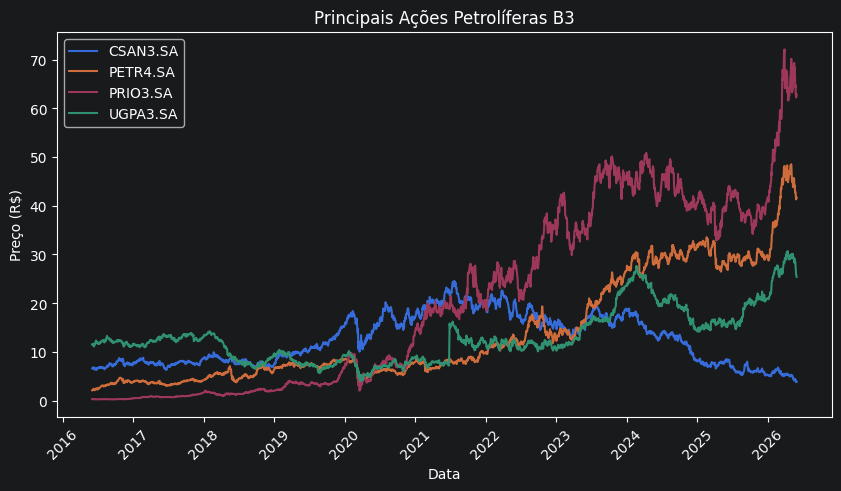

In [28]:
#Visualizando os dados:
plt.figure(figsize=(10,5))
plt.title('Principais Ações Petrolíferas B3')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.plot(df_cotacoes)
plt.legend(df_cotacoes.columns)
plt.show()

In [29]:
#Separando os dados em treino e teste, utilizando a métrica 80/20
tamanho_treino = int(len(df_cotacoes)*0.8)
dados_treino = df_cotacoes.iloc[:tamanho_treino]
dados_teste = df_cotacoes.iloc[tamanho_treino:]
print(len(dados_treino), len(dados_teste))

1993 499


In [32]:
#Normalizando os dados utilizando o min max scaller para o intervalo (0,1)
#MinMax scaller vai escalar cada coluna individualmente (pois são 6 ações diferentes)
scaler = MinMaxScaler(feature_range=(0, 1))

#É interessante escalar apenas os dados de treino, para evitar data leakage (vazamento de dados)
treino_escalado = scaler.fit_transform(dados_treino)
teste_escalado = scaler.transform(dados_teste)

In [33]:
#Criando a função que trabalha com a janela temporal dos dados
def criar_sequencias(dados, janela=60):
    x, y = [], []
    for i in range(janela, len(dados)):
        x.append(dados[i-janela:i]) #Historico da janela tempral, no caso os ultimos 60 dias
        y.append(dados[i]) #Preço alvo do dia atual (para as 4 ações)
    return np.array(x), np.array(y)

In [34]:
#Definindo a janela temporal e criando os dados de treino
janela_temporal = 60 #padrão para analise de ações (2meses)

x_treino, y_treino = criar_sequencias(treino_escalado, janela_temporal)

In [35]:
#Criando e ajustando os dados de teste
#É necessário a concatenação dos ultimos dias de treino para não perder o inicio do teste
total_dados_teste = pd.concat((dados_treino.tail(janela_temporal), dados_teste), axis=0)
total_dados_escalado = scaler.transform(total_dados_teste)

#Criando os dados de teste
x_teste, y_teste = criar_sequencias(total_dados_escalado, janela_temporal)

In [36]:
print(f"Formato Treino: {x_treino.shape}, {y_treino.shape}")
print(f"Formato Teste: {x_teste.shape}, {y_teste.shape}")

Formato Treino: (1933, 60, 4), (1933, 4)
Formato Teste: (499, 60, 4), (499, 4)


In [37]:
#Construindo o modelo

#Dimensões:
passos = x_treino.shape[1] #60 dias
recursos = x_treino.shape[2] #as 4 ações

modelo = Sequential(
    [LSTM(units=50, return_sequences=True, input_shape=(passos, recursos)),
     Dropout(0.2),
     LSTM(units=50, return_sequences=False),
     Dropout(0.2),
     Dense(units=recursos), #Por se tratar de 4 ações diferentes a camada Dense tem que ter exatamente 6 neuronios de saída
    ])


C:\Users\Rafael\PyCharmMiscProject\.venv313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
#Após testes anteriores, adicionar um critério de parada antecipada, se faz necessário
early_stop = EarlyStopping(
    monitor='val_loss', #monitora a perda nos dados de teste
    patience=10, #Interrompe, se o erro não melhora por 5 épocas seguidas
    restore_best_weights=True, #garante que o modelo final, utilizará os pesos da melhor época
    verbose=1 #comunica em qual época o treino foi interrompido
)

In [39]:
#Compilando o modelo
modelo.compile(optimizer='adam', loss='mse')
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,404 (122.67 KB)

 Trainable params: 31,404 (122.67 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Treinando o modelo
historico = modelo.fit(x_treino, y_treino, epochs=50, batch_size=32, validation_data=(x_teste, y_teste), callbacks=[early_stop])

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0301 - val_loss: 0.0302
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0071 - val_loss: 0.0177
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0055 - val_loss: 0.0154
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0049 - val_loss: 0.0122
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0047 - val_loss: 0.0110
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0043 - val_loss: 0.0113
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0039 - val_loss: 0.0113
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0035 - val_loss: 0.0097
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034 - val_loss: 0.0085
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0032 - val_loss: 0.0082
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0032 - val_loss: 0.0106
Epoch 12/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0

In [41]:
#Realizar as predições com o modelo treinado, e reverter a normalização (scaler) dos dados
#predições modelo treinado
predicoes_escaladas = modelo.predict(x_teste)

#Desfazer a normalização dos dados
predicoes_reais = scaler.inverse_transform(predicoes_escaladas)

#Desfazer a normalização dos dados de teste
y_teste_real = scaler.inverse_transform(y_teste)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [42]:
#Criar novos dataframes, para facilitar a maniopulação dos dados
coluna_acoes = df_cotacoes.columns
df_reais = pd.DataFrame(y_teste_real, columns=coluna_acoes, index=dados_teste.index)
df_predicoes = pd.DataFrame(predicoes_reais, columns=coluna_acoes, index=dados_teste.index)

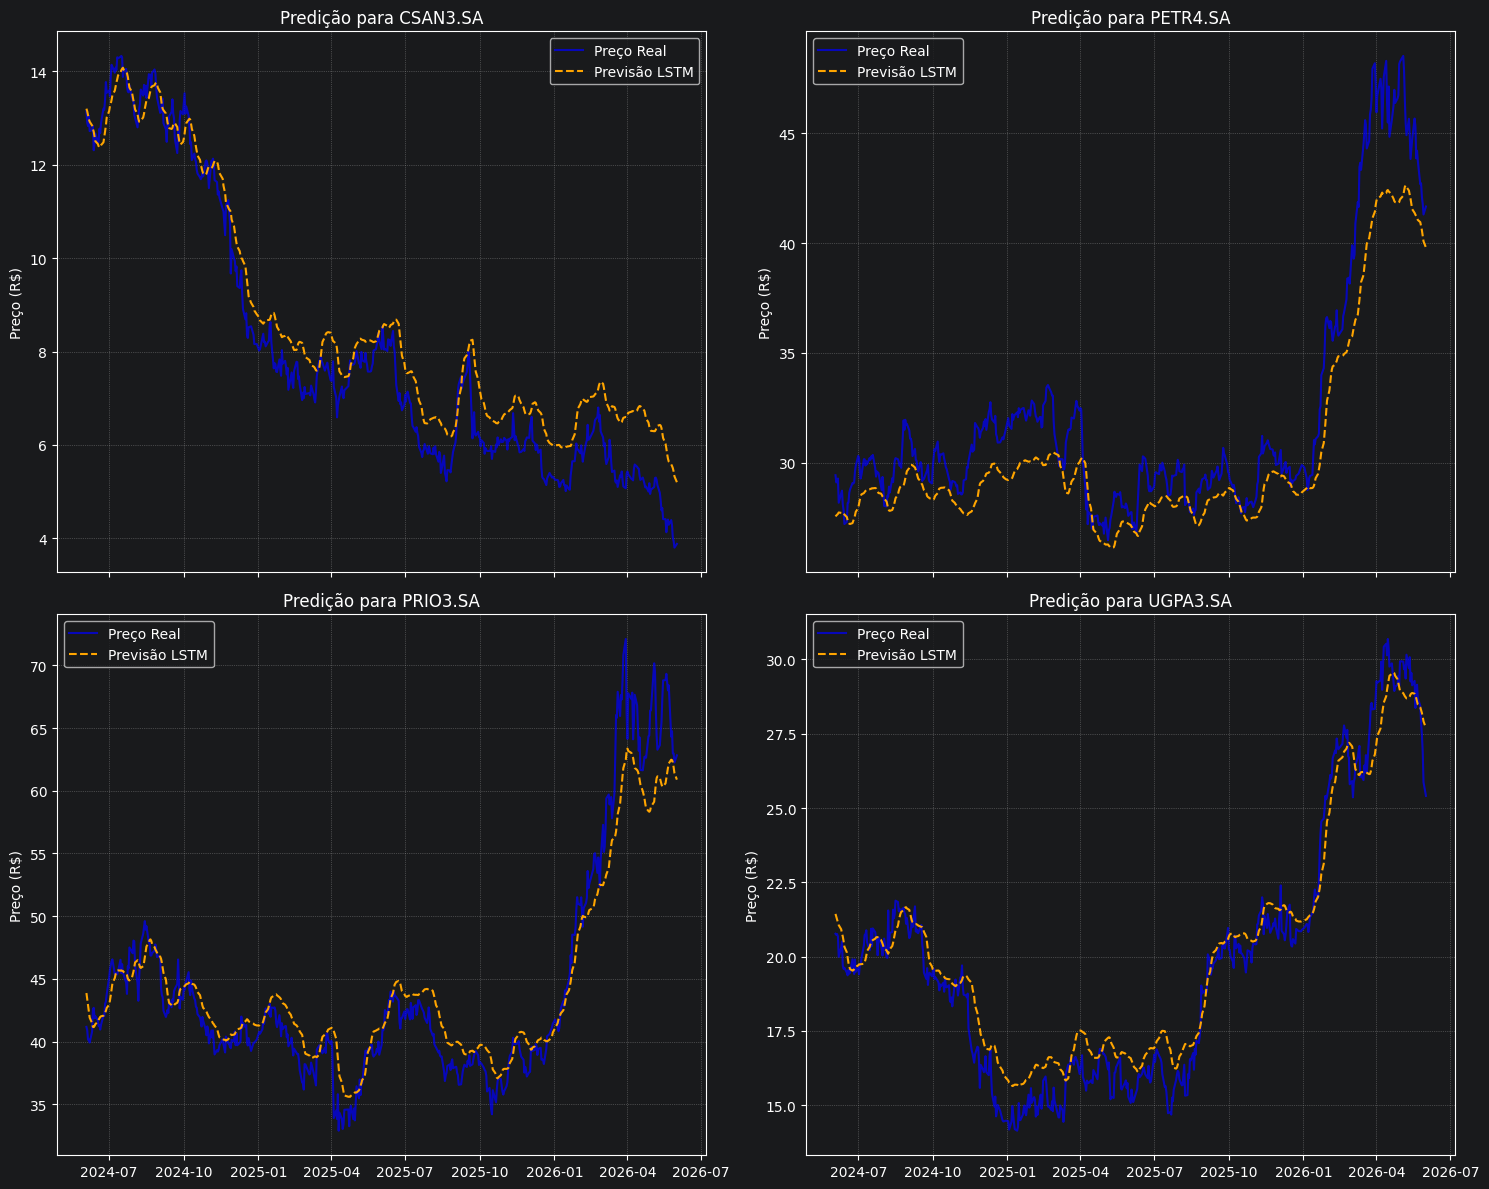

In [44]:
#Graficando o resultado dos 4 papeis:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True)
axes = axes.flatten()

# Iterar sobre cada ação para gerar os subplots
for i, acao in enumerate(coluna_acoes):
    axes[i].plot(df_reais[acao], label='Preço Real', color='blue', alpha=0.7)
    axes[i].plot(df_predicoes[acao], label='Previsão LSTM', color='orange', linestyle='--')
    axes[i].set_title(f'Predição para {acao.upper()}')
    axes[i].set_ylabel('Preço (R$)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [45]:
#Avaliar numericamente a precisão do modelo em cada ativo, utilizando o RSME e o MAE

print('---Desempenho do Modelo por Ação (Valores Absolutos e Percentuais---')
for acao in coluna_acoes:

    #Cálculo dos Erros Absoluto em R$
    rmse = np.sqrt(mean_squared_error(df_reais[acao], df_predicoes[acao]))
    mae = mean_absolute_error(df_reais[acao], df_predicoes[acao])

    #Média dos preços reais da ação no período de teste
    preco_medio_real = df_reais[acao].mean()

    #Transformar os erros em porcentagem em relação à media do preco
    rmse_pct = (rmse/preco_medio_real)*100

    #Calculo MAPE (média das variações percentuais ponto a ponto)
    mae_pct = np.mean(np.abs(df_reais[acao] - df_predicoes[acao])/df_reais[acao])*100

    #Exibição dos resultados:
    print(f"\n📌 {acao}:")
    print(f"   RMSE: R$ {rmse:.2f} ({rmse_pct:.2f}%)")
    print(f"   MAE:  R$ {mae:.2f} ({mae_pct:.2f}%)")

---Desempenho do Modelo por Ação (Valores Absolutos e Percentuais---

📌 CSAN3.SA:
   RMSE: R$ 0.79 (9.67%)
   MAE:  R$ 0.67 (10.49%)

📌 PETR4.SA:
   RMSE: R$ 2.22 (6.93%)
   MAE:  R$ 1.75 (5.12%)

📌 PRIO3.SA:
   RMSE: R$ 2.61 (5.89%)
   MAE:  R$ 1.88 (4.06%)

📌 UGPA3.SA:
   RMSE: R$ 0.93 (4.67%)
   MAE:  R$ 0.75 (4.07%)
